## Pumpkin Varieties and Color

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

Let's look at the relationship between color and variety

In [1]:
import pandas as pd
import numpy as np

full_pumpkins = pd.read_csv('../data/US-pumpkins.csv')

full_pumpkins.head()



,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [3]:
#select the columns we want to use
columns_to_select = ['City Name','Package', 'Variety',  'Origin', 'Item Size', 'Color']
pumpkins = full_pumpkins.loc[ : ,columns_to_select]

In [4]:
#drop rows with missing values
pumpkins.dropna(inplace=True)
pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


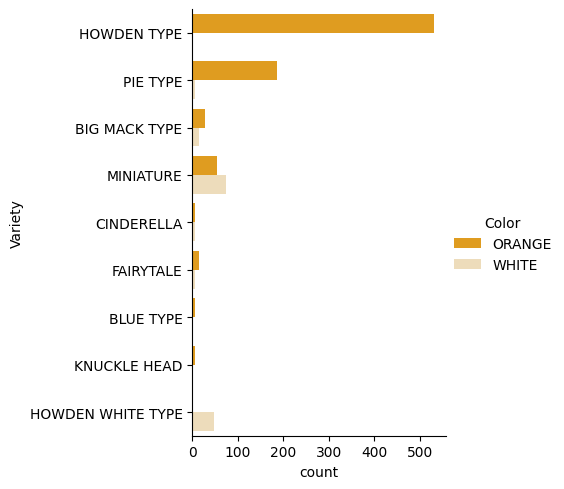

In [5]:
import seaborn as sns
#specify colors for each values of the hue variable
palette = {'ORANGE': 'orange', 
           'WHITE': 'wheat'}

#plıt a bar plot to visualize how many pumpkins of each variety are orange or white
sns.catplot(data=pumpkins, y='Variety', hue='Color', kind='count', palette=palette)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
#encode the item size column using ordinal encoding
item_size_categories = [['sml', 'med','med-lge','lge','xlge','jbo','exjbo']]
ordinal_features = ['Item Size']#Hangi kolon(lar)ın ordinal (sıralı) kategorik olduğunu belirtir
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)
#Item Size sütunundaki metinleri Yukarıda verdiğin sıraya göre Sayılara çevirecek


In [ ]:
from sklearn.preprocessing import OneHotEncoder
#encode all the other features using one hot encoding
categorical_features = ['City Name','Package', 'Variety',  'Origin']
#Hangi kolon(lar)ın nominal (sırasız) kategorik olduğunu belirtir
categorical_encoder = OneHotEncoder(sparse_output=False)
#sparse_output=False --> çıktı olarak sparse matrix değil normal array verir

In [ ]:
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(
    transformers=[
        ('ord', ordinal_encoder, ordinal_features),
        ('cat', categorical_encoder, categorical_features)
    ]
)
#ColumnTransformer, birden fazla kodlayıcıyı tek bir adımda 
# birleştirmek ve bunları uygun sütunlara uygulamak için kullanılır.

#get the encode features as a pandas dataframe
ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(pumpkins)
encoded_features.head()


,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_MICHIGAN,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
from sklearn.preprocessing import LabelEncoder 
#encode thecolor column using label encoding
label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(pumpkins['Color'])
encoded_pumpkins = encoded_features.assign(Color=encoded_label)
encoded_pumpkins.head()


,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA,Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [20]:
#lets look at the mapping between the encoded values and original values
list(label_encoder.inverse_transform([0,1]))  #0 --> 'ORANGE', 1 --> 'WHITE'

['ORANGE', 'WHITE']

/var/folders/yp/pkv5qv7x6v11fn_9wtqqf68w0000gn/T/ipykernel_71307/3520137943.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=pumpkins,
/opt/anaconda3/envs/.virtualenvs/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


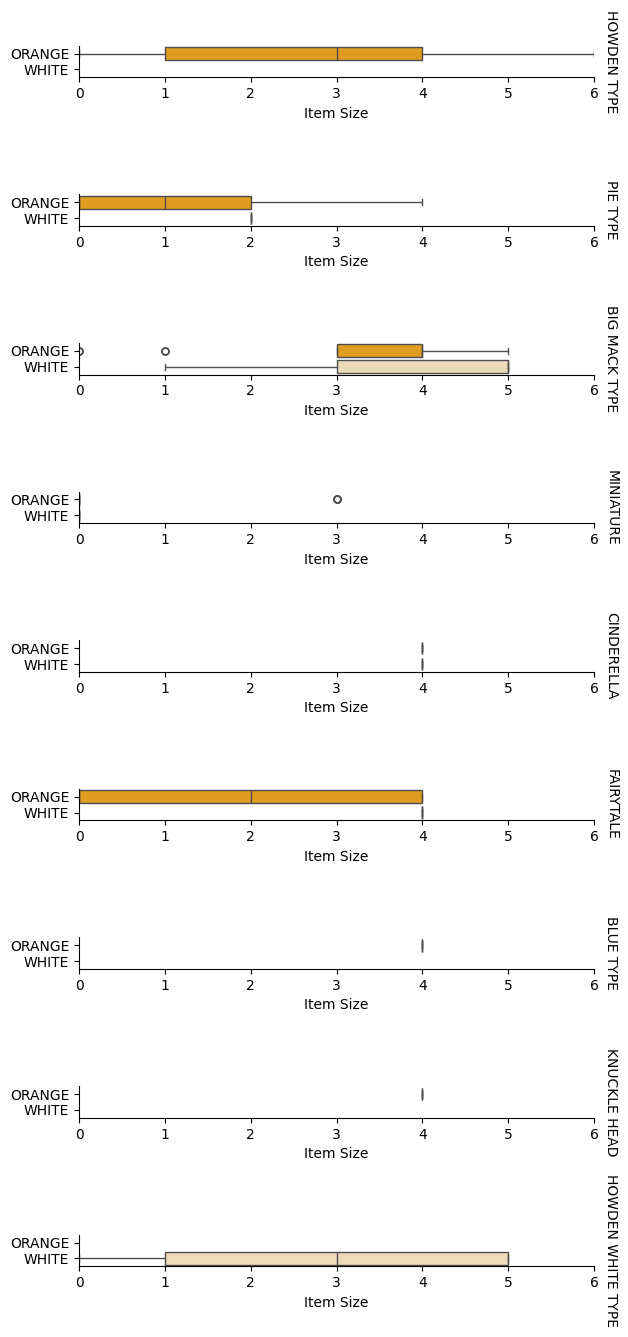

In [23]:
palette = {'ORANGE': 'orange', 
           'WHITE': 'wheat'}

#we need the encoded item size column to use it as the x axis values in the plot
pumpkins['Item Size'] = encoded_pumpkins['ord__Item Size']

g = sns.catplot(data=pumpkins, 
                x='Item Size', y='Color', row='Variety', 
                kind='box', orient='h',
                sharex=False, margin_titles=True,
                height=1.5, aspect=4, palette=palette)

#defining axis labels 
g.set(xlabel="Item Size" , ylabel = "").set(xlim=(0,6))
g.set_titles(row_template="{row_name}")

/opt/anaconda3/envs/.virtualenvs/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 63.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/.virtualenvs/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 21.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Color', ylabel='ord__Item Size'>

/opt/anaconda3/envs/.virtualenvs/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 79.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/.virtualenvs/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


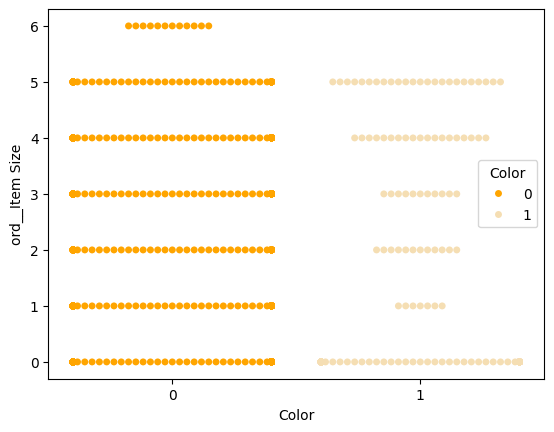

In [25]:
#ürün boyutu ve renk arasındaki ilişkiyi anlamak için
palette = {0: 'orange', 
           1: 'wheat'}
sns.swarmplot(x="Color", y="ord__Item Size", data=encoded_pumpkins, hue="Color", palette=palette)

In [ ]:
from sklearn.model_selection import train_test_split

#x is the encoded features 
X = encoded_pumpkins[encoded_pumpkins.columns.difference(['Color'])]
#y is the encoded labels
y = encoded_pumpkins['Color']

#split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [33]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

#evaluate the model and print the results
print(classification_report(y_test, predictions))
print('Predicted labels: ', predictions)
print('F1-score: ', f1_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1]
F1-score:  0.7457627118644068


In [30]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)
#162 dogru turuncu tahmin true negatives , 
#22 dogru beyaz tahmin true positives
#4 yanlış turuncu beyaz tahmin false positives
#11 yanlış beyaz turuncu tahmin false negatives

array([[162,   4],
       [ 11,  22]])

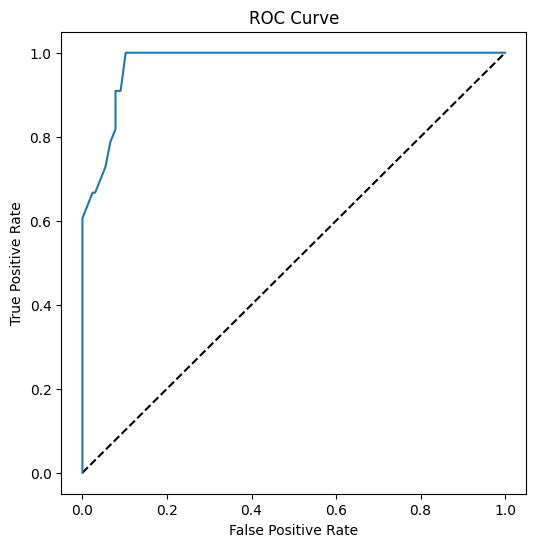

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

y_scores = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
#Modelinin tüm threshold değerlerinde
#doğru pozitif – yanlış pozitif dengesini
#ROC Curve ile görselleştirdin

In [ ]:
"""
ROC eğrileri tipik olarak Y ekseninde gerçek pozitif orana ve 
X ekseninde yanlış pozitif orana sahiptir."
Bu nedenle, eğrinin dikliği ve orta nokta çizgisi ile eğri arasındaki boşluk önemlidir: 
hızla yukarı ve çizginin üzerine doğru bir eğri istersiniz.
"""

auc = roc_auc_score(y_test,y_scores[:,1])
#egri altındaki alanı hesaplayarak modelin sınıflandırma başarısını buluyor
print(auc)

0.9749908725812341
